In [ ]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt

In [24]:
blocks = pd.read_csv("blocks.csv")
gdf_blocks = gpd.GeoDataFrame(blocks, geometry=gpd.points_from_xy(blocks.lon, blocks.lat), crs="EPSG:4326").to_crs(32618)
blocks_pop = pd.read_csv("nhgis0002_ds258_2020_block.csv")

C:\Users\logan\AppData\Local\Temp\ipykernel_37368\1568750189.py:3: DtypeWarning: Columns (23,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  blocks_pop = pd.read_csv("nhgis0002_ds258_2020_block.csv")


In [25]:
pantries = pd.read_csv("pantries_new.csv")
gdf_pantry = gpd.GeoDataFrame(pantries,geometry=gpd.points_from_xy(pantries.Long, pantries.Lat),crs="EPSG:4326").to_crs(32618)

In [26]:
pantry_ids = gdf_pantry["Pantry"].tolist()

# Normalize lot size (acres)
gdf_pantry["lot_norm"] = gdf_pantry["lot_acres"] / gdf_pantry["lot_acres"].mean()

blocks_pop = blocks_pop[['GEOCODE', 'U7H001']].copy()
blocks_pop.rename(columns={'GEOCODE': 'BLOCK_GEOID20', 'U7H001': 'population'}, inplace=True)
blocks_pop['BLOCK_GEOID20'] = blocks_pop['BLOCK_GEOID20'].astype(str)
gdf_blocks['BLOCK_GEOID20'] = gdf_blocks['BLOCK_GEOID20'].astype(str)
gdf_blocks = gdf_blocks.merge(blocks_pop, on='BLOCK_GEOID20', how='left')

In [27]:
decay_rate = 0.765  # 23.5% drop per mile

def decay(d_miles):
    return decay_rate ** d_miles

alpha = 1.0   # decay influence
beta  = 0.4   # lot size influence (tunable)

for pid in pantry_ids:
    pantry_row = gdf_pantry.loc[gdf_pantry["Pantry"] == pid].iloc[0]
    pantry_point = pantry_row.geometry
    lot_norm = pantry_row["lot_norm"]

    # distance in miles from each block to this pantry
    distances = gdf_blocks.geometry.distance(pantry_point) / 1609.34

    # distance decay
    D_ij = decay(distances)

    # attractiveness = distance decay * normalized lot size
    gdf_blocks[f"A_{pid}"] = (D_ij ** alpha) * (lot_norm ** beta)


In [28]:
A_cols = [f"A_{pid}" for pid in pantry_ids]
A_sum = gdf_blocks[A_cols].sum(axis=1)

for pid in pantry_ids:
    gdf_blocks[f"P_{pid}"] = gdf_blocks[f"A_{pid}"] / A_sum


In [29]:
# convert to fraction 0–1 if needed
if gdf_blocks["poverty_rate_est"].max() > 1.5:  # crude check
    gdf_blocks["poverty_frac"] = gdf_blocks["poverty_rate_est"] / 100.0
else:
    gdf_blocks["poverty_frac"] = gdf_blocks["poverty_rate_est"]

## Choose one of the next three blocks.

$Demand_{ij} = population_i \cdot poverty\_frac_i \cdot P_{ij}$

In [ ]:
for pid in pantry_ids:
    gdf_blocks[f"demand_{pid}"] = gdf_blocks["poverty_frac"] * gdf_blocks[f"P_{pid}"] * gdf_blocks["population"]


$Demand_{ij} = population_i \cdot poverty\_frac_i \cdot (P_{ij}^{(1)} + 0.4P_{ij}^{(2)})$

In [44]:
P_cols = [f"P_{pid}" for pid in pantry_ids]

w2 = 0.4  # 40% second-choice supplementation

# First and second choice PROBABILITY values
gdf_blocks["first_prob_value"]  = gdf_blocks[P_cols].max(axis=1)
gdf_blocks["second_prob_value"] = gdf_blocks[P_cols].apply(lambda row: row.nlargest(2).iloc[-1], axis=1)


# First and second choice NAMES
gdf_blocks["first_pantry"]  = gdf_blocks[P_cols].idxmax(axis=1)
gdf_blocks["second_pantry"] = gdf_blocks[P_cols].apply(lambda row: row.nlargest(2).index[-1], axis=1)


# Calculate demand contributions separately
for pid in pantry_ids:
    D1 = gdf_blocks.apply(lambda row: row["first_prob_value"]  if row["first_pantry"]  == f"P_{pid}" else 0, axis=1)
    D2 = gdf_blocks.apply(lambda row: row["second_prob_value"] if row["second_pantry"] == f"P_{pid}" else 0, axis=1)

    gdf_blocks[f"demand_{pid}"] = (
        gdf_blocks["population"] * gdf_blocks["poverty_frac"] * (D1 + w2 * D2)   # **first gets 100%, second gets 40%**
    )

$Demand_{ij} = population_i \cdot poverty\_frac_i \cdot (P_{ij}^{(1)} + 0.4P_{ij}^{(2)} + 0.2P_{ij}^{(3)})$

In [30]:
P_cols = [f"P_{pid}" for pid in pantry_ids]

w1 = 1.0
w2 = 0.4
w3 = 0.2


gdf_blocks["first_prob_value"]  = gdf_blocks[P_cols].max(axis=1)
gdf_blocks["second_prob_value"] = gdf_blocks[P_cols].apply(lambda row: row.nlargest(2).iloc[-1], axis=1)
gdf_blocks["third_prob_value"] = gdf_blocks[P_cols].apply(lambda row: row.nlargest(3).iloc[-1], axis=1)

gdf_blocks["first_pantry"]  = gdf_blocks[P_cols].idxmax(axis=1)
gdf_blocks["second_pantry"] = gdf_blocks[P_cols].apply(lambda row: row.nlargest(2).index[-1], axis=1)
gdf_blocks["third_pantry"]  = gdf_blocks[P_cols].apply(lambda row: row.nlargest(3).index[-1], axis=1)

for pid in pantry_ids:
    D1 = gdf_blocks.apply(lambda row: row["first_prob_value"]  if row["first_pantry"]  == f"P_{pid}" else 0, axis=1)
    D2 = gdf_blocks.apply(lambda row: row["second_prob_value"] if row["second_pantry"] == f"P_{pid}" else 0, axis=1)
    D3 = gdf_blocks.apply(lambda row: row["third_prob_value"]  if row["third_pantry"]  == f"P_{pid}" else 0, axis=1)
    
    gdf_blocks[f"demand_{pid}"] = (
        gdf_blocks["population"] * gdf_blocks["poverty_frac"] * (w1*D1 + w2*D2 + w3*D3)
    )


In [31]:
pantry_demand = {
    pid: gdf_blocks[f"demand_{pid}"].sum()
    for pid in pantry_ids
}
print(pantry_demand)


{'NEW Enfield Food Distribution': 911.4036125760354, 'Tompkins Community Action': 1687.5840077113703, 'St. Johns Community Services Pantry': 0.0, 'Ithaca Free Clinic': 0.0, 'Salvation Army SK- Ithaca Saturday FP': 1241.6509226635271, 'Immaculate Conception Food Pantry': 123.51059382071196, 'Baptized Church of Jesus Christ': 0.0, 'Ithaca Kitchen Cupboard': 910.4045961983333}


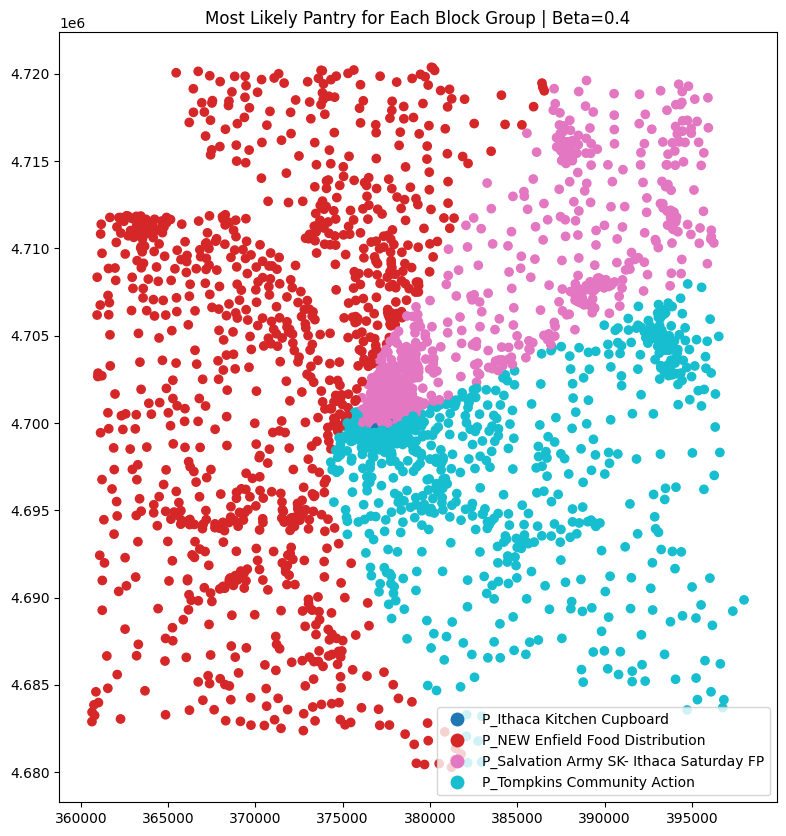

In [32]:
gdf_blocks["best_pantry"] = gdf_blocks[[f"P_{pid}" for pid in pantry_ids]].idxmax(axis=1)
# gdf_blocks["best_pantry"] = gdf_blocks["best_pantry"].str.extract("(\d+)").astype(int)

gdf_blocks.plot(
    column="best_pantry",
    cmap="tab10",
    legend=True,
    figsize=(10, 10)
)
plt.title(f"Most Likely Pantry for Each Block Group | Beta={beta}")
plt.show()
 

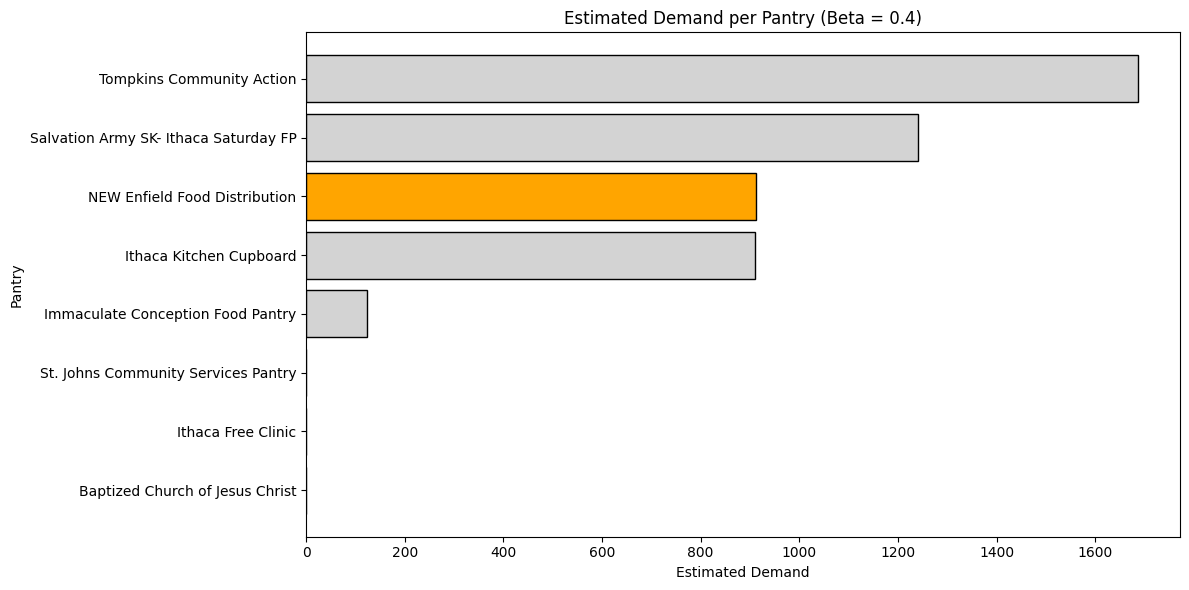

In [33]:
sorted_items = sorted(pantry_demand.items(), key=lambda kv: kv[1], reverse=True)
pantry_names = [name for name, val in sorted_items]
demand_values = [val for name, val in sorted_items]

highlight_name1 = "Enfield Food Distribution"
highlight_name2 = "NEW Enfield Food Distribution"

# Define colors: highlighted = accent color, others = neutral
colors = [
    "orange" if name == highlight_name1 or name == highlight_name2 else "lightgray"
    for name in pantry_names
]

plt.figure(figsize=(12, 6))
plt.barh(pantry_names, demand_values, color=colors, edgecolor="black")
plt.xlabel("Estimated Demand")
plt.ylabel("Pantry")
plt.title(f"Estimated Demand per Pantry (Beta = {beta})")
plt.gca().invert_yaxis()  # optional: largest on top
plt.tight_layout()
plt.show()